In [28]:
# --- Célula 1: imports e carga do modelo ---
import os
import cv2
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

CAMINHO_BASE       = os.path.join(os.path.dirname(os.getcwd()), 'data')
CAMINHO_NORMALIZED = os.path.join(CAMINHO_BASE, 'normalized')
CAMINHO_OUTPUT     = os.path.join(CAMINHO_BASE, 'output')
CAMINHO_MODELO     = os.path.join(CAMINHO_BASE, '..', 'runs_sinuca', 'deteccao_bola', 'weights', 'best.pt')

modelo_yolo = YOLO(CAMINHO_MODELO)

In [29]:
# --- Célula 2: extração de features + classificação com arbitragem v7 ---

def extrair_features_bola(recorte_bgr):
    if recorte_bgr.size == 0:
        return None

    hsv = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]

    raio = int(min(h, w) * 0.42)
    mascara = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mascara, (w // 2, h // 2), raio, 255, -1)
    area_bola = cv2.countNonZero(mascara)
    if area_bola < 10:
        return None

    idx = mascara > 0
    S_vals = hsv[:, :, 1][idx].astype(np.float32)
    V_vals = hsv[:, :, 2][idx].astype(np.float32)

    v_mediana = float(np.median(V_vals))
    razao_colorida = float(np.count_nonzero(S_vals > 90)) / area_bola

    glare = (V_vals > 245) & (S_vals < 25)
    branco_real = (S_vals < 55) & (V_vals > 150) & (~glare)
    razao_branco = float(np.count_nonzero(branco_real)) / area_bola

    mascara_colorida = ((hsv[:, :, 1] > 90) & (mascara > 0)).astype(np.uint8)
    n_labels, labels = cv2.connectedComponents(mascara_colorida)
    maior_blob = 0
    for label in range(1, n_labels):
        tamanho = np.count_nonzero(labels == label)
        maior_blob = max(maior_blob, tamanho)
    maior_blob_razao = float(maior_blob) / area_bola

    return {
        'v_mediana': v_mediana,
        'razao_colorida': razao_colorida,
        'razao_branco': razao_branco,
        'maior_blob_razao': maior_blob_razao,
    }


def classificar_tipo_local(feats):
    if feats['v_mediana'] < 60:
        return 'preta'
    if feats['razao_colorida'] <= 0.1:
        return 'branca'
    if feats['razao_colorida'] <= 0.72:
        return 'lisa' if feats['razao_branco'] <= 0.08 else 'listrada'
    return 'lisa'


def eh_candidata_viavel_branca(feats):
    """Filtro de viabilidade calibrado nos dados reais (árvore de decisão,
    100% de acerto nas 9 bolas que historicamente disputaram o título):
    branca real é sempre muito clara E não tem área branca extrema demais
    (o que sinaliza listrada com faixa muito larga visível, não branca)."""
    return feats['v_mediana'] > 186.5 and feats['razao_branco'] <= 0.61


def classificar_bolas_frame(recortes):
    """Classifica todas as bolas de um frame, arbitrando a branca em 2 etapas:
    1) Filtro de viabilidade (v_mediana + razao_branco) — corta candidatas
       que nem deveriam estar na disputa (ex: listrada escura, ou listrada
       com área branca extrema demais).
    2) Entre as que sobraram, desempate por menor blob colorido contíguo.
    """
    n = len(recortes)
    features = [extrair_features_bola(r) for r in recortes]

    tipos = [None] * n
    candidatas_branca = []

    for i, feats in enumerate(features):
        if feats is None:
            tipos[i] = 'lisa'
            continue

        if feats['v_mediana'] < 60:
            tipos[i] = 'preta'
            continue

        if feats['razao_colorida'] <= 0.18:
            candidatas_branca.append(i)
        else:
            tipos[i] = classificar_tipo_local(feats)

    # Etapa 1: filtro de viabilidade
    viaveis = [i for i in candidatas_branca if eh_candidata_viavel_branca(features[i])]
    nao_viaveis = [i for i in candidatas_branca if i not in viaveis]

    # Candidatas que falharam o filtro de viabilidade voltam pra regra normal
    for i in nao_viaveis:
        tipos[i] = 'lisa' if features[i]['razao_branco'] <= 0.08 else 'listrada'

    if len(viaveis) == 0:
        pass  # nenhuma bola branca detectada neste frame (raro, mas possível se a branca estiver fora de quadro)
    elif len(viaveis) == 1:
        tipos[viaveis[0]] = 'branca'
    else:
        # Mais de uma passou o filtro de viabilidade: desempata por menor
        # blob colorido contíguo, depois maior v_mediana.
        vencedora = min(
            viaveis,
            key=lambda i: (features[i]['maior_blob_razao'], -features[i]['v_mediana'])
        )
        for i in viaveis:
            if i == vencedora:
                tipos[i] = 'branca'
            else:
                tipos[i] = 'lisa' if features[i]['razao_branco'] <= 0.08 else 'listrada'

    return tipos

In [30]:
# --- Célula 3: detecção + classificação numa imagem ---
def detectar_bolas_e_cacapas(imagem, modelo, conf=0.35):
    altura, largura = imagem.shape[:2]
    resultados = {'cacapas': [], 'bolas': []}

    # Caçapas — mantém o mapeamento fixo (mesa já normalizada por homografia)
    margem_x = int(largura * 0.02)
    margem_y = int(altura * 0.04)
    resultados['cacapas'] = [
        {'posicao': 'superior_esq',  'x': margem_x,           'y': margem_y},
        {'posicao': 'superior_meio', 'x': largura // 2,       'y': margem_y},
        {'posicao': 'superior_dir',  'x': largura - margem_x, 'y': margem_y},
        {'posicao': 'inferior_esq',  'x': margem_x,           'y': altura - margem_y},
        {'posicao': 'inferior_meio', 'x': largura // 2,       'y': altura - margem_y},
        {'posicao': 'inferior_dir',  'x': largura - margem_x, 'y': altura - margem_y},
    ]

    # Inferência YOLO
    pred = modelo.predict(imagem, conf=conf, verbose=False)[0]


    # dentro de detectar_bolas_e_cacapas, troque o loop por:
    recortes = []
    caixas = []
    for box in pred.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(largura, x2), min(altura, y2)
        recortes.append(imagem[y1:y2, x1:x2])
        caixas.append((x1, y1, x2, y2, float(box.conf[0])))

    tipos = classificar_bolas_frame(recortes)

    for (x1, y1, x2, y2, conf), tipo in zip(caixas, tipos):
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        raio = max((x2 - x1), (y2 - y1)) // 2
        resultados['bolas'].append({'tipo': tipo, 'x': cx, 'y': cy, 'raio': raio, 'confianca': round(conf, 3)})

    return resultados

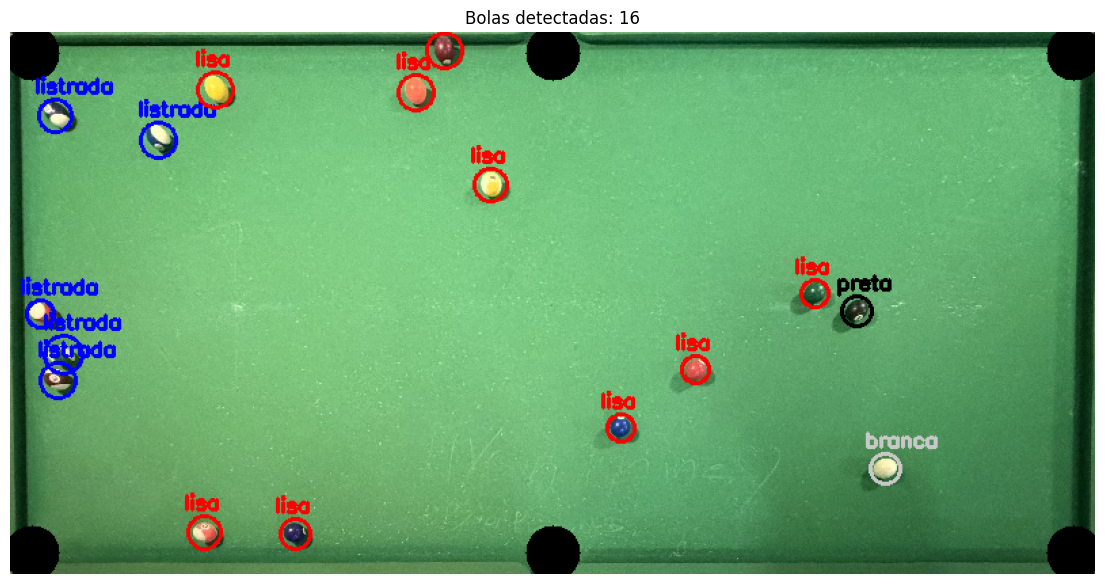

Resultados salvos: /home/bridge/SinucaVision/data/output/IMG_0640/IMG_0640_balls.json


In [31]:
# --- Célula 4: roda numa imagem de teste e visualiza ---
nome_ficheiro = 'IMG_0640.JPG'
nome_base     = os.path.splitext(nome_ficheiro)[0]
caminho_img   = os.path.join(CAMINHO_NORMALIZED, nome_ficheiro)
imagem        = cv2.imread(caminho_img)

dados = detectar_bolas_e_cacapas(imagem, modelo_yolo)

vis = imagem.copy()

# Desenha as caçapas (estava faltando!)
for cacapa in dados['cacapas']:
    cv2.circle(vis, (cacapa['x'], cacapa['y']), 20, (0, 0, 0), -1)

# Desenha as bolas
for bola in dados['bolas']:
    cx, cy, raio, tipo = bola['x'], bola['y'], bola['raio'], bola['tipo']
    cor = {'branca': (200, 200, 200), 'preta': (0, 0, 0),
           'listrada': (255, 0, 0), 'lisa': (0, 0, 255)}.get(tipo, (0, 255, 0))
    cv2.circle(vis, (cx, cy), raio, cor, 2)
    cv2.putText(vis, tipo, (cx - 15, cy - raio - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"Bolas detectadas: {len(dados['bolas'])}")
plt.axis('off')
plt.show()

# Salva o JSON (estava faltando essa célula inteira!)
pasta = os.path.join(CAMINHO_OUTPUT, nome_base)
os.makedirs(pasta, exist_ok=True)
caminho_json = os.path.join(pasta, f'{nome_base}_balls.json')
with open(caminho_json, 'w', encoding='utf-8') as f:
    json.dump(dados, f, indent=4, ensure_ascii=False)
print(f'Resultados salvos: {caminho_json}')

In [32]:
# --- Célula 5 (ATUALIZADA): processa TODAS as imagens salvando diretamente em data/output ---
imagens = sorted(glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.JPG')))
imagens += sorted(glob.glob(os.path.join(CAMINHO_NORMALIZED, '*.jpg')))
print(f'Imagens encontradas: {len(imagens)}')

for caminho_img in imagens:
    nome_ficheiro = os.path.basename(caminho_img)
    nome_base     = os.path.splitext(nome_ficheiro)[0]
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        print(f'  [ERRO] Não foi possível carregar {nome_ficheiro}')
        continue

    dados   = detectar_bolas_e_cacapas(imagem, modelo_yolo)
    n_bolas = len(dados['bolas'])
    
    # Salva o JSON diretamente em CAMINHO_OUTPUT
    caminho_json = os.path.join(CAMINHO_OUTPUT, f'{nome_base}_balls.json')
    with open(caminho_json, 'w', encoding='utf-8') as f:
        json.dump(dados, f, indent=4, ensure_ascii=False)
    
    tipos   = {t: sum(1 for b in dados['bolas'] if b['tipo'] == t)
               for t in ['branca', 'preta', 'lisa', 'listrada']}

    status = '✓' if tipos['branca'] == 1 else '⚠ sem branca (ou mais de 1)'
    print(f'  {status}  {nome_ficheiro}: {n_bolas} bolas '
          f'(branca={tipos["branca"]}, preta={tipos["preta"]}, '
          f'lisas={tipos["lisa"]}, listradas={tipos["listrada"]})')

print(f'\nConcluído: {len(imagens)} imagens → JSONs salvos em {CAMINHO_OUTPUT}')

Imagens encontradas: 6
  ✓  IMG_0640.JPG: 16 bolas (branca=1, preta=1, lisas=9, listradas=5)
  ✓  IMG_0641.JPG: 16 bolas (branca=1, preta=1, lisas=7, listradas=7)
  ✓  IMG_0642.JPG: 16 bolas (branca=1, preta=1, lisas=7, listradas=7)
  ✓  IMG_0643.JPG: 15 bolas (branca=1, preta=1, lisas=6, listradas=7)
  ✓  IMG_0644.JPG: 15 bolas (branca=1, preta=1, lisas=7, listradas=6)
  ✓  IMG_0645.JPG: 15 bolas (branca=1, preta=1, lisas=7, listradas=6)

Concluído: 6 imagens → JSONs salvos em /home/bridge/SinucaVision/data/output


In [33]:
# --- Célula 6 (NOVA): visualização em lote a partir dos JSONs salvos ---
COR_TIPO = {
    'branca':   (240, 240, 240),
    'preta':    (20, 20, 20),
    'lisa':     (255, 165, 0),
    'listrada': (80, 160, 255),
}

arquivos_json = sorted(glob.glob(
    os.path.join(CAMINHO_OUTPUT, '**', '*_balls.json'), recursive=True))
print(f'JSONs encontrados: {len(arquivos_json)}')

for caminho_json in arquivos_json:
    nome_base   = os.path.basename(caminho_json).replace('_balls.json', '')
    pasta_saida = os.path.dirname(caminho_json)

    caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.JPG')
    if not os.path.exists(caminho_img):
        caminho_img = os.path.join(CAMINHO_NORMALIZED, nome_base + '.jpg')
    imagem = cv2.imread(caminho_img)
    if imagem is None:
        print(f'  [ERRO] Imagem não encontrada: {caminho_img}')
        continue

    with open(caminho_json, 'r') as f:
        dados = json.load(f)

    bolas = dados['bolas']
    n_b = sum(1 for b in bolas if b['tipo'] == 'branca')
    n_p = sum(1 for b in bolas if b['tipo'] == 'preta')
    n_l = sum(1 for b in bolas if b['tipo'] == 'lisa')
    n_s = sum(1 for b in bolas if b['tipo'] == 'listrada')

    vis = cv2.cvtColor(imagem.copy(), cv2.COLOR_BGR2RGB)
    for cacapa in dados['cacapas']:
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (30, 30, 30), -1)
        cv2.circle(vis, (cacapa['x'], cacapa['y']), 12, (180, 180, 180), 2)

    for idx, bola in enumerate(bolas, 1):
        cx, cy = bola['x'], bola['y']
        raio   = bola.get('raio', 15)
        cor    = COR_TIPO.get(bola['tipo'], (200, 200, 200))
        cv2.circle(vis, (cx, cy), raio + 3, cor, 2)
        cv2.putText(vis, str(idx), (cx - 5, cy - raio - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, cor, 1, cv2.LINE_AA)

    aviso = '' if n_b == 1 else '  ⚠ BRANCA NÃO DETECTADA / DUPLICADA'
    titulo = (f'{nome_base}  |  {len(bolas)} bolas  '
              f'(branca={n_b}  preta={n_p}  lisas={n_l}  listradas={n_s}){aviso}')

    plt.figure(figsize=(12, 7))
    plt.imshow(vis)
    plt.title(titulo, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    caminho_viz = os.path.join(pasta_saida, f'{nome_base}_viz.png')
    plt.savefig(caminho_viz, dpi=130, bbox_inches='tight')
    plt.close()

    print(f'  ✓  {nome_base}/ → _viz.png  ({len(bolas)} bolas: {n_b}B {n_p}P {n_l}L {n_s}S)')

print(f'\nVisualizações salvas em data/output/<nome>/')

JSONs encontrados: 12
  ✓  IMG_0640/ → _viz.png  (16 bolas: 1B 1P 9L 5S)
  ✓  IMG_0640/ → _viz.png  (16 bolas: 1B 1P 9L 5S)
  ✓  IMG_0641/ → _viz.png  (16 bolas: 1B 1P 7L 7S)
  ✓  IMG_0641/ → _viz.png  (16 bolas: 1B 1P 7L 7S)
  ✓  IMG_0642/ → _viz.png  (16 bolas: 1B 1P 7L 7S)
  ✓  IMG_0642/ → _viz.png  (16 bolas: 1B 1P 7L 7S)
  ✓  IMG_0643/ → _viz.png  (15 bolas: 1B 1P 6L 7S)
  ✓  IMG_0643/ → _viz.png  (15 bolas: 1B 1P 6L 7S)
  ✓  IMG_0644/ → _viz.png  (15 bolas: 1B 1P 7L 6S)
  ✓  IMG_0644/ → _viz.png  (15 bolas: 1B 1P 7L 6S)
  ✓  IMG_0645/ → _viz.png  (15 bolas: 1B 1P 7L 6S)
  ✓  IMG_0645/ → _viz.png  (15 bolas: 1B 1P 7L 6S)

Visualizações salvas em data/output/<nome>/
